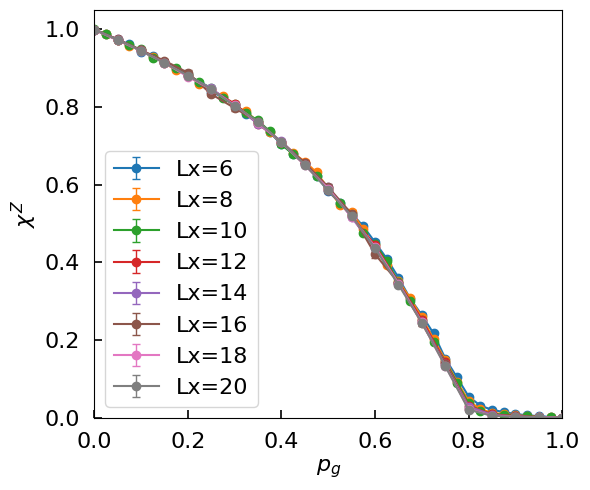

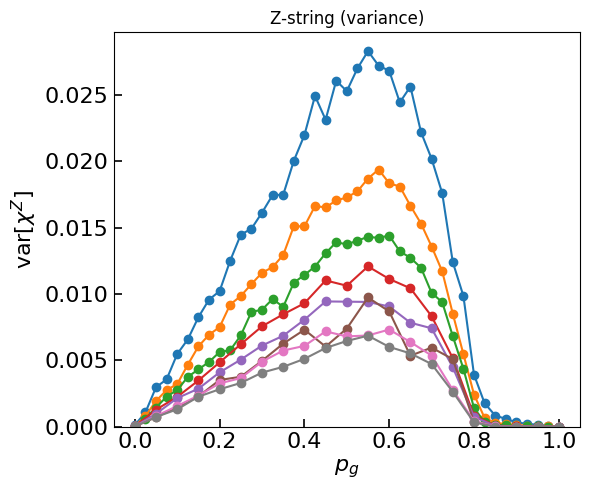

initial state = product X, Z-string_0.0-1.0


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import re

# ファイルを取得
files = glob.glob("results_px_0.0_Lx_*_Nd_*_NT_*_with_err.npz")

# (Lx, Nd, NT, filename) のタプルを作ってソート
file_info = []
for fname in files:
    match = re.search(r"Lx_(\d+)_Nd_(\d+)_NT_(\d+)_with_err.npz", fname)
    if match:
        Lx, Nd, NT = map(int, match.groups())
        file_info.append((Lx, Nd, NT, fname))
# Lx の昇順でソート
file_info.sort(key=lambda x: x[0])

# --- average 用の figure ---
fig_avg, ax_avg = plt.subplots(figsize=(6,5))

# --- variance 用の figure ---
fig_var, ax_var = plt.subplots(figsize=(6,5))

for Lx, Nd, NT, fname in file_info:
    data = np.load(fname)
    pg = data["pg"]
    R2z_ave = data["R2z_ave"]
    R2z_err = data["R2z_err"]
    R2z_var = data["R2z_var"]
    order = np.argsort(pg)
    pg = pg[order]
    R2z_ave = R2z_ave[order]
    R2z_err = R2z_err[order]
    R2z_var = R2z_var[order]
    # 平均のプロット
    ax_avg.errorbar(pg, R2z_ave, R2z_err, fmt="-o", capsize=3, elinewidth=1, capthick=1, label=f"Lx={Lx}")
    # 分散のプロット
    ax_var.plot(pg, R2z_var, marker="o", label=f"Lx={Lx}")

# --- average figure の整L形 ---
ax_avg.set_xlabel("$p_g$",fontsize=16)
ax_avg.set_ylabel("$\chi^Z$",fontsize=16)
ax_avg.set_xlim(0,1.0)
ax_avg.set_ylim(0)
#ax_avg.set_title("Z-string (average)")
ax_avg.legend(fontsize=16)
ax_avg.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=16)
ax_avg.tick_params(axis='both', which='major',pad=10)
ax_avg.grid(False)
fig_avg.tight_layout()
fig_avg.savefig("fig_px_0_zstring_ave_00-10.svg", dpi=300, bbox_inches="tight", transparent=True)

# --- variance figure の整形 ---
ax_var.set_xlabel("$p_g$",fontsize=16)
ax_var.set_ylabel("$\mathrm{var}[\chi^Z]$",fontsize=16)
ax_var.set_ylim(0)
ax_var.set_title("Z-string (variance)")
#ax_var.legend(ncol=2, fontsize=9)
ax_var.tick_params(axis='both', which='major',
                    direction="in",    # 内向きに（物理系論文でよく使う）
                    length=6, width=1.2,
                    labelsize=16)
ax_var.grid(False)
fig_var.tight_layout()
#fig_var.savefig("Zstring_variance.png", dpi=300, bbox_inches="tight")

plt.show()

print("initial state = product X, Z-string_0.0-1.0")
